# Лекция 1. Знакомство с обучением с подкреплением

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IlyaChichkanov/Reinforcement-learning/blob/main/01-intro/lecture/lecture.ipynb)

**Цели лекции**

1. Выделить отличительные черты Reinforcement Learning и понимать, где он применяется.
2. Освоить словарь RL — агент, среда, состояние, действие, награда, политика, эпизод, return, MDP — **на одном живом примере**, а не по определениям.
3. Научиться измерять качество политики и улучшать её: написать первый рабочий алгоритм RL, метод Cross-Entropy.

Один и тот же клеточный мир — замёрзшее озеро — пройдёт с нами всю лекцию: на нём мы введём каждое понятие, научимся измерять политику и напишем алгоритм, который сам найдёт дорогу к цели. А в конце тот же алгоритм, ничего не зная про физику, научит машинку заезжать на горку.

**План и хронометраж (одна пара, 90 минут)**

| | Раздел | Минут |
|---|---|---|
| 1 | Как устроен курс | 5 |
| 2 | Что такое Reinforcement Learning | 5 |
| 3 | Три вида машинного обучения | 8 |
| 4 | Где применяется RL | 6 |
| 5 | Ключевые понятия на живом примере: Frozen Lake | 12 |
| 6 | Другие среды и упражнение «определите сами» | 6 |
| 7 | Живые демо: CartPole и тележка на горке | 8 |
| 8 | Марковское свойство и MDP | 7 |
| 9 | Награда — это формулировка задачи | 4 |
| 10 | Исследование и использование | 4 |
| 11 | Как измерить политику: Монте-Карло и ценность состояния | 7 |
| 12 | Первый алгоритм: метод Cross-Entropy | 15 |
| 13 | Карта курса и итоги | 3 |
| | **Итого** | **90** |

Пометки в заголовках: **📖 дома** — материал для самостоятельного чтения, на лекции можно пропустить; **⏱ если есть время** — резерв. Все ячейки с кодом лучше прогнать один раз до лекции (целиком ноутбук выполняется около двух минут, дольше всего — обучение на горке в разделе 12).

In [1]:
# Если ноутбук открыт в Google Colab: ставим недостающие пакеты. Локально (после uv sync) ячейка ничего не делает.
import importlib.util, subprocess, sys
if importlib.util.find_spec("gymnasium") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gymnasium[toy-text,classic-control]"], check=True)

## 1. Как устроен курс

* **16 недель**, одно занятие в неделю: лекция + семинар. Каждая неделя — папка `NN-topic-name/` в репозитории с тремя ноутбуками: `lecture/`, `seminar/`, `homework/`.
* **Домашние задания** почти каждую неделю, в `.ipynb`. Часть проверок — через `assert`, так что можно проверить себя до сдачи.
* **Оценка** (черновик, обсуждаем сегодня): 60% домашние задания, 30% итоговый проект, 10% активность на семинарах.
* **Итоговый проект**: своя реализация RL-агента или мини-исследование на среде по выбору. Темы выбираем на неделе 14, защита на неделе 16.
* **Инструменты**: Python 3.10+, [Gymnasium](https://gymnasium.farama.org/) (среды), [PyTorch](https://pytorch.org/) (нейросети), Jupyter.
  Библиотеки [Stable-Baselines3](https://stable-baselines3.readthedocs.io/) и [CleanRL](https://github.com/vwxyzjn/cleanrl) читаем как справочник, но алгоритмы в домашках пишем сами.
* **Что нужно уметь на входе**: линейная алгебра, теория вероятностей, Python с numpy. Нейросети и PyTorch — желательно, но **не обязательно**: до недели 5, где они впервые понадобятся, есть месяц. Для тех, кто с нейросетями не работал, в репозитории два ноутбука для самостоятельной работы: `../seminar/dl_basics.ipynb` (нейросети с нуля: модель, функция потерь, градиентный спуск, первая сеть на PyTorch) и `../seminar/pytorch_intro.ipynb` (механика PyTorch, которая нужна именно в RL). Дорожная карта — в конце лекции и в README.

Установка окружения:

```bash
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
```

## 2. Что такое Reinforcement Learning

Начнём с картинки, которую все понимают без определений: дрессировщик и собака.

<img src="https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/ref/agent_env_dog.png" width="420">

Собака **наблюдает** (жест, голос), **действует** (садится, лает, убегает), а дрессировщик выдаёт **награду** (лакомство есть или нет). Никто не объясняет собаке, *как* правильно, есть только последствия. Через десяток повторений действие, за которым идёт лакомство, случается чаще. Это и есть обучение с подкреплением.

Та же схема в общем виде:

<img src="https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/ref/agent_env_brain.png" width="420">

* **Агент** — тот, кто принимает решения (мозг, программа). Единственное, что мы обучаем.
* **Среда** — всё остальное: физический мир, игра, биржа, другой игрок.
* На каждом шаге $t$ агент видит **состояние** $S_t$ (или наблюдение), выбирает **действие** $A_t$, среда отвечает **наградой** $R_t$ и новым состоянием $S_{t+1}$.

**Цель агента** — максимизировать суммарную награду

$$
G = \sum_{t=0}^{\infty} \gamma^t R_t, \qquad \gamma \in [0, 1].
$$

Вопрос залу: как научить собаку команде, если объяснить словами вы ничего не можете? Ответ — единственный доступный канал связи: поощрять то, что похоже на нужное поведение. Дальше вся лекция про то, как это записать формально и запрограммировать: в разделе 5 каждое слово из этой картинки станет строчкой кода.

**Reinforcement Learning (RL)** — раздел машинного обучения о том, как агент, взаимодействуя со средой, учится выбирать действия так, чтобы суммарная награда была как можно больше.

<small>Иллюстрации в этом разделе и в разделах 5–6 — из лекции 1 курса [imm-rl-lab](https://github.com/imm-rl-lab/reinforcement_learning_course) (А. Плаксин).</small>

## 3. Три вида машинного обучения

Где RL живёт на карте машинного обучения? Три большие группы задач отличаются не алгоритмами, а тем, **какие данные доступны** и **откуда берётся сигнал для обучения**.

![paradigms](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/ml_paradigms.png)

**Обучение с учителем (supervised).** Дана таблица примеров с правильными ответами — пары $(x_i, y_i)$; модель ищет $f(x) \approx y$, ошибка на каждом примере известна сразу.

* спам-фильтр: $x$ — текст письма, $y$ — «спам / не спам» (разметку сделали люди кнопкой «в спам»);
* диагностика по снимку: $x$ — рентген, $y$ — диагноз врача;
* прогноз спроса: $x$ — день недели, погода, цена; $y$ — сколько продали.

**Обучение без учителя (unsupervised).** Ответов нет, есть только объекты $x_i$; задача — найти структуру.

* кластеризация клиентов: на какие группы делятся покупатели (сколько групп — заранее не знает никто);
* поиск аномалий: транзакция не похожа на остальные — возможно, мошенничество;
* эмбеддинги и снижение размерности: сжать 10 000 признаков в 50, сохранив «похожесть».

**Обучение с подкреплением (reinforcement).** Ни таблицы с ответами, ни фиксированного набора данных. Есть **среда**, в которой агент действует, и **награда** — число в ответ на действия.

* игра: агент видит экран, нажимает кнопки, в конце партии узнаёт, выиграл или проиграл;
* робот: подаёт токи на моторы, награда — прошёл ли метр и не упал ли;
* охлаждение дата-центра: меняет уставки кондиционеров, награда — минус потраченная энергия при соблюдении температуры.

Вопрос залу: сколько размеченных примеров нужно, чтобы обучить робота ходить «с учителем»? Столько, сколько правильных траекторий для каждой ситуации вы готовы записать руками, — и это главная причина, почему такой подход не работает.

| | Supervised | Unsupervised | Reinforcement |
|---|---|---|---|
| Что дано | пары $(x, y)$ | только $x$ | среда для взаимодействия |
| Обратная связь | правильный ответ сразу | нет | награда, часто с задержкой |
| Откуда данные | собраны заранее | собраны заранее | порождает сам агент |
| Что оптимизируем | ошибку предсказания | структуру в данных | суммарную награду |
| Решения влияют на данные | нет | нет | **да** |

**Четыре отличительные черты RL**

1. **Нет правильного ответа, есть оценка.** Учитель не говорит «здесь нужно было повернуть налево», есть только число.
2. **Отложенная награда.** В шахматах результат приходит через 40 ходов после решающей ошибки: какое из 40 действий виновато? Это задача **credit assignment**.
3. **Данные порождает сам агент.** Плохая политика видит только плохие состояния; данные не независимы и меняются по ходу обучения.
4. **Нужно исследовать.** Чтобы найти лучшее поведение, надо пробовать новое, а новое в среднем невыгодно (раздел 10).

Границы, конечно, размыты: RL умеет пользоваться и разметкой (imitation learning — учимся повторять за экспертом), и предобученными представлениями. А в разделе 12 мы увидим алгоритм, который на каждом шаге превращает задачу RL в обычную задачу обучения с учителем — на данных, которые агент собрал себе сам.

Дальше вся лекция — про третью колонку этой таблицы. Сначала посмотрим, где это применяют, а потом разберём словарь RL на живом примере.

### Разминка: какой это тип обучения?

Два вопроса на каждый пункт: *есть ли правильные ответы* и *влияют ли решения модели на будущие данные*.

1. По истории поездок предсказать время в пути до университета.
2. Научить манипулятор перекладывать детали; известен только процент успешно переложенных.
3. Разбить 50 000 отзывов на тематические группы, чтобы понять, на что жалуются.
4. Подобрать порядок новостей в ленте так, чтобы пользователь читал больше в течение месяца.

<details>
<summary>Ответы</summary>

1. **Supervised**: для каждой прошлой поездки известно фактическое время.
2. **Reinforcement**: правильная траектория неизвестна, есть только результат попытки.
3. **Unsupervised**: разметки тем нет.
4. **Reinforcement**: правильного порядка не существует, награда отложена на месяц, и лента сама определяет, какие данные мы увидим завтра.

</details>

## 4. Где применяется RL

Общий рецепт: как только у задачи есть **среда** (или её симулятор) и **числовая цель**, поведение можно не программировать, а выучить.

![timeline](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/rl_timeline.png)

### Игры

| Год | Система | Что произошло | Посмотреть |
|---|---|---|---|
| 1992 | **TD-Gammon** | Нейросеть учится играть в нарды сама с собой и выходит на уровень чемпионов мира. | [статья](https://dl.acm.org/doi/10.1145/203330.203343) |
| 2015 | **DQN** | Одна сеть учится играть в 49 игр Atari по пикселям и счёту. | [видео Breakout](https://www.youtube.com/watch?v=TmPfTpjtdgg), [Nature](https://www.nature.com/articles/nature14236) |
| 2016 | **AlphaGo** | Победа над Ли Седолем в го. | [фильм](https://www.youtube.com/watch?v=WXuK6gekU1Y) |
| 2017 | **AlphaZero** | Шахматы, сёги и го с нуля, только игрой с самим собой. | [блог](https://deepmind.google/discover/blog/alphazero-shedding-new-light-on-chess-shogi-and-go/) |
| 2019 | **OpenAI Five**, **AlphaStar** | Dota 2 и StarCraft II на уровне профессионалов. | [OpenAI Five](https://openai.com/index/openai-five/), [AlphaStar](https://deepmind.google/discover/blog/alphastar-mastering-the-real-time-strategy-game-starcraft-ii/) |

Почему игры: есть симулятор, чёткая награда и можно сыграть миллионы партий. OpenAI Five за время обучения наиграла эквивалент десятков тысяч лет Dota 2.

> **Факт.** Во второй партии с Ли Седолем AlphaGo сыграл 37-й ход, который комментаторы сочли ошибкой: вероятность такого хода у человека оценивали как один к десяти тысячам. Партию AlphaGo выиграл, а ход вошёл в учебники го.
>
> **Факт.** В 2025 году Ричард Саттон и Эндрю Барто получили **премию Тьюринга** (аналог Нобелевской в информатике) за создание reinforcement learning. Область, с которой мы начинаем, молодая: её основателям вручили главную премию буквально на днях.

### Робототехника

Общая схема: учим в симуляторе, переносим на железо (sim-to-real). [Роботы-футболисты DeepMind](https://sites.google.com/view/op3-soccer), [ходьба четвероногих ANYmal](https://arxiv.org/abs/1901.08652), [Boston Dynamics Spot](https://bostondynamics.com/blog/starting-on-the-right-foot-with-reinforcement-learning/), [кубик Рубика одной рукой](https://openai.com/index/solving-rubiks-cube/).

> **Факт.** В 2023 году дрон, обученный с подкреплением ([Swift](https://www.nature.com/articles/s41586-023-06419-4)), обыграл чемпионов мира по гонкам дронов на их же трассе.

### Управление инфраструктурой

* [Охлаждение дата-центров Google](https://deepmind.google/discover/blog/deepmind-ai-reduces-google-data-centre-cooling-bill-by-40/): минус 40% энергии на охлаждение. Состояние — сотни датчиков, действия — уставки оборудования, награда — сэкономленная энергия при соблюдении температурных ограничений.
* [Управление плазмой в токамаке](https://www.nature.com/articles/s41586-021-04301-9), светофоры, [размещение блоков на чипе](https://deepmind.google/discover/blog/how-alphachip-transformed-computer-chip-design/).

### Финансы, рои дронов, рекомендации

**Биржа**: исполнение крупных ордеров, маркет-мейкинг, портфель. Честная оговорка: рынок нестационарен и шумный, это гораздо труднее Atari ([обзор](https://arxiv.org/abs/1911.10107), [FinRL](https://github.com/AI4Finance-Foundation/FinRL)). **Рои дронов**: каждый дрон видит только соседей, награда общая — это multi-agent RL, неделя 15 ([полёт роя сквозь лес](https://arxiv.org/abs/2202.03308)). **Рекомендации**: что показать, чтобы пользователь остался надолго, а не только кликнул сейчас.

### Языковые модели

Ответы модели на 1.3 млрд параметров, дообученной с помощью RL на человеческих предпочтениях, люди предпочитали ответам модели на 175 млрд параметров без такого дообучения. Это **RLHF** ([InstructGPT](https://arxiv.org/abs/2203.02155)) — благодаря ему ChatGPT стал полезным собеседником; **рассуждающие модели** ([DeepSeek-R1](https://arxiv.org/abs/2501.12948)) обучены RL на проверяемых наградах.

Во всех этих задачах — от нард до языковых моделей — один и тот же словарь: среда, состояние, действие, награда, политика. Разберём его на самом простом примере, который поместится на экран целиком.

## 5. Ключевые понятия на живом примере: Frozen Lake

Словарь RL мы будем вводить не определениями, а на одной конкретной среде, которая пройдёт с нами всю лекцию, семинар и домашнее задание. Это **Frozen Lake** из библиотеки [Gymnasium](https://gymnasium.farama.org/) — стандартного интерфейса к средам, в котором будут жить все среды курса.

<img src="https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/ref/frozen_lake.png" width="260">

Агент стоит на замёрзшем озере 4×4 и хочет дойти от старта `S` до цели `G`, не провалившись в прорубь `H`. Пока лёд у нас **не скользкий**: куда попросили, туда и пошёл (скользкий вариант появится в разделе 8).

Первая ячейка ниже — служебная: в ней только функции для картинок (нарисовать карту, маршрут, стрелки политики). Её нужно запустить, но читать не обязательно.

In [2]:
# Служебный код для картинок: запустить и не читать. Содержательный код начинается со следующей ячейки.
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from matplotlib import animation
from IPython.display import HTML, display

ARROWS = "←↓→↑"                      # так пронумерованы действия в Frozen Lake: 0=←, 1=↓, 2=→, 3=↑
CELL_COLORS = {"S": "#f2f2f2", "F": "#ffffff", "H": "#a8c8ec", "G": "#a9dfa9"}

def lake_desc(env):
    """Карта озера как список строк: ['SFFF', 'FHFH', 'FFFH', 'HFFG']."""
    return ["".join(c.decode() for c in row) for row in env.unwrapped.desc]

def draw_lake(desc, ax=None, size=3.0):
    """Пустая карта озера. Возвращает оси, поверх которых можно рисовать маршруты и стрелки."""
    nrow, ncol = len(desc), len(desc[0])
    if ax is None:
        _, ax = plt.subplots(figsize=(size, size * nrow / ncol))
    ax.set_xlim(0, ncol); ax.set_ylim(nrow, 0); ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
    for r in range(nrow):
        for c in range(ncol):
            ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=CELL_COLORS[desc[r][c]], edgecolor="k", lw=0.6))
            if desc[r][c] in "SHG":
                ax.text(c + 0.5, r + 0.82, desc[r][c], ha="center", va="center", fontsize=8, color="#666")
    return ax

def draw_paths(sessions, desc, ax=None, title="", color="C0", alpha=0.35, size=3.0):
    """Маршруты эпизодов поверх карты: ломаная через центры клеток, точка — где эпизод закончился."""
    ax = draw_lake(desc, ax, size)
    ncol, rng = len(desc[0]), np.random.default_rng(0)
    for states, *_ in sessions:
        pts = np.array([divmod(int(s), ncol) for s in states], float) + 0.5 + rng.normal(0, 0.07, (len(states), 2))
        ax.plot(pts[:, 1], pts[:, 0], color=color, alpha=alpha, lw=1.5)
        ax.plot(pts[-1, 1], pts[-1, 0], "o", color=color, alpha=alpha, ms=4)
    ax.set_title(title, fontsize=10)
    return ax

def draw_policy(policy, desc, ax=None, title="", size=3.0):
    """Стрелка — самое вероятное действие, насыщенность — его вероятность; «·» — строка почти равномерная."""
    ax = draw_lake(desc, ax, size)
    ncol = len(desc[0])
    for s, p in enumerate(policy):
        r, c = divmod(s, ncol)
        if desc[r][c] in "HG":
            continue
        a, top2 = int(np.argmax(p)), np.sort(p)[-2:]
        if top2[1] - top2[0] < 0.05:
            ax.text(c + 0.5, r + 0.5, "·", ha="center", va="center", fontsize=18, color="grey")
        else:
            ax.text(c + 0.5, r + 0.5, ARROWS[a], ha="center", va="center", fontsize=20, alpha=0.2 + 0.8 * float(p[a]))
    ax.set_title(title, fontsize=10)
    return ax

def plot_values(values, desc, ax=None, title="", vmax=None, size=3.0):
    """Тепловая карта ценности клеток (проруби и цель — терминальные, у них ценность 0 по определению)."""
    nrow, ncol = len(desc), len(desc[0])
    ax = draw_lake(desc, ax, size)
    grid = np.asarray(values, float).reshape(nrow, ncol)
    vmax = vmax or max(float(np.nanmax(grid)), 1e-9)
    for r in range(nrow):
        for c in range(ncol):
            if desc[r][c] in "HG":
                continue
            if np.isnan(grid[r, c]):                     # клетку ни разу не посещали — оценки нет
                ax.text(c + 0.5, r + 0.5, "—", ha="center", va="center", fontsize=9, color="grey")
                continue
            ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=plt.cm.YlOrRd(0.85 * grid[r, c] / vmax), edgecolor="k", lw=0.6))
            ax.text(c + 0.5, r + 0.5, f"{grid[r, c]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(title, fontsize=10)
    return ax

def plot_returns(returns, threshold=None, elite_mask=None, ax=None, title=""):
    """Каждая точка — эпизод, по вертикали его return (как на схеме метода Cross-Entropy)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4.6, 3.2))
    returns, x = np.asarray(returns, float), np.random.default_rng(0).uniform(0, 1, len(returns))
    if elite_mask is None:
        ax.scatter(x, returns, s=22, color="C0", alpha=0.7)
    else:
        m = np.asarray(elite_mask, bool)
        ax.scatter(x[~m], returns[~m], s=18, color="grey", alpha=0.35, label=f"остальные ({(~m).sum()})")
        ax.scatter(x[m], returns[m], s=42, color="C2", alpha=0.95, edgecolors="white", label=f"элита ({m.sum()})")
        ax.legend(loc="upper right", fontsize=8)
    if threshold is not None:
        ax.axhline(threshold, ls="--", color="C3", lw=1.5)
        ax.text(0.0, threshold + 0.02, f"порог = {threshold:.2f}", color="C3", fontsize=8)
    ax.set_xticks([]); ax.set_ylabel("return"); ax.set_ylim(-0.05, 1.05); ax.set_title(title, fontsize=10)
    return ax

def animate_policy(policies, rates, desc, interval=500):
    """Кадр — одна итерация обучения: стрелки политики и доля успешных эпизодов."""
    nrow, ncol = len(desc), len(desc[0])
    fig, ax = plt.subplots(figsize=(3.4, 3.4 * nrow / ncol + 0.3)); plt.close(fig)
    def frame(k):
        ax.clear(); draw_policy(policies[k], desc, ax=ax, title=f"итерация {k}: доля успехов {rates[k]:.0%}")
    anim = animation.FuncAnimation(fig, frame, frames=len(policies), interval=interval)
    return HTML(anim.to_jshtml(default_mode="loop"))

def show_frames(frames, title="", interval=60, width=3.2):
    """Кадры среды -> анимация в ноутбуке (в превью на GitHub не видна, только при запуске)."""
    h, w = frames[0].shape[:2]
    fig, ax = plt.subplots(figsize=(width, width * h / w))
    ax.axis("off"); ax.set_title(title, fontsize=10)
    im = ax.imshow(frames[0]); plt.close(fig)
    anim = animation.FuncAnimation(fig, lambda i: (im.set_data(frames[i]),), frames=len(frames), interval=interval, blit=True)
    return HTML(anim.to_jshtml(default_mode="loop"))

SFFF
FHFH
FFFH
HFFG


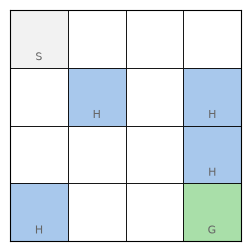

In [3]:
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
desc = lake_desc(env)                         # карта как список строк
print("\n".join(desc))
draw_lake(desc); plt.show()

### Состояние

**Состояние** $S_t$ — описание ситуации в среде, которого достаточно, чтобы принять решение. Здесь это номер клетки от 0 до 15 (по строкам, слева направо: старт — 0, цель — 15). В CartPole состоянием будут четыре числа, в Atari — кадр с экрана, но роль одна и та же. Когда агент видит не всё (покер, туман войны), говорят о **наблюдении** $O_t$ — об этом на неделе 2; пока состояние и наблюдение совпадают.

`env.reset()` начинает новый эпизод и возвращает первое состояние. `observation_space` и `action_space` описывают, какими бывают состояния и действия.

In [4]:
state, info = env.reset(seed=0)
print("состояние после reset:", state, " (клетка S)")
print("observation_space:", env.observation_space, "— 16 клеток")
print("action_space:     ", env.action_space, " — 0=←, 1=↓, 2=→, 3=↑")

состояние после reset: 0  (клетка S)
observation_space: Discrete(16) — 16 клеток
action_space:      Discrete(4)  — 0=←, 1=↓, 2=→, 3=↑


### Действие, награда, переход

**Действие** $A_t$ — то, чем агент влияет на среду: здесь четыре направления. Действия бывают **дискретными** (направления, кнопки джойстика) и **непрерывными** (момент на суставе робота).

`env.step(a)` выполняет действие и возвращает пять значений: новое состояние, **награду** $R_t$, два флага окончания эпизода и служебный словарь. Сделаем шесть шагов руками — прямо по кратчайшему пути к цели.

In [5]:
env.reset(seed=0)
for a in [2, 2, 1, 1, 1, 2]:                                   # →, →, ↓, ↓, ↓, →
    state, reward, terminated, truncated, info = env.step(a)
    print(f"действие {ARROWS[a]}: новое состояние {state:2d}, награда {reward}, terminated={terminated}")

действие →: новое состояние  1, награда 0, terminated=False
действие →: новое состояние  2, награда 0, terminated=False
действие ↓: новое состояние  6, награда 0, terminated=False
действие ↓: новое состояние 10, награда 0, terminated=False
действие ↓: новое состояние 14, награда 0, terminated=False
действие →: новое состояние 15, награда 1, terminated=True


Обратите внимание на две вещи.

* **Награда** — единственный сигнал обучения, и здесь он очень скупой: 0 на каждом шаге и 1 только за вход в цель. Агент не знает, какое действие было «правильным», он знает только, сколько ему заплатили. За провал в прорубь платят тоже 0, а не −1: озеро не наказывает, оно просто не награждает.
* После входа в цель `terminated=True`: цель — **терминальное состояние**, из него взаимодействие не продолжается. Прорубь — тоже терминальное состояние. Одна траектория от `reset()` до терминального состояния называется **эпизодом**; следующий эпизод начинается новым `reset()`.

Второй флаг, `truncated`, означает другое: эпизод оборвали снаружи по лимиту шагов (в Frozen Lake это 100), хотя среда могла бы продолжаться. Путать их нельзя: после `terminated` будущих наград нет, после `truncated` — есть, просто мы их не увидели.

### Политика

**Политика** $\pi$ — правило выбора действия по состоянию. Это единственное, что мы обучаем. Пока состояний и действий конечное число, политику удобно хранить **таблицей** 16 × 4: строка — состояние, столбец — действие, в клетке — вероятность его выбрать:

$$
\pi[s, a] = \mathbb{P}[A_t = a \mid S_t = s], \qquad \sum_a \pi[s, a] = 1 \ \ \text{для каждого } s .
$$

Такая политика **стохастическая**: в одном и том же состоянии она может выбрать разные действия. Стохастичность не для красоты: пока агент учится, он обязан пробовать разное (раздел 10). Начнём с самой простой политики — **равномерной**: в каждой клетке агент бросает кубик.

Чтобы сыграть эпизод политикой-таблицей, нужен цикл из пяти строк: посмотреть состояние, выбрать действие из строки таблицы, сделать шаг, запомнить, что было. Эта функция будет использоваться до конца лекции.

строка политики для клетки 0: [0.25 0.25 0.25 0.25]
состояния: [0, 4, 4, 4, 0, 0, 1, 2, 3, 3, 3, 2, 2, 1, 2, 1, 1, 2, 6, 10, 9, 8, 9, 10, 11]
действия:  ↓←←↑↑→→→↑↑←↑←→←↑→↓↓←←→→→
награды:   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


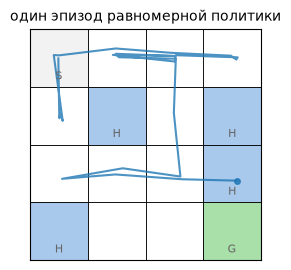

In [6]:
def run_session(env, policy, rng, max_steps=100):
    """Один эпизод политикой-таблицей policy. Возвращает состояния (включая последнее), действия и награды."""
    s, _ = env.reset(seed=int(rng.integers(1_000_000)))
    states, actions, rewards = [s], [], []
    for _ in range(max_steps):
        a = int(rng.choice(len(policy[s]), p=policy[s]))      # действие ~ π(· | s)
        s, r, terminated, truncated, _ = env.step(a)
        states.append(s); actions.append(a); rewards.append(r)
        if terminated or truncated:
            break
    return states, actions, rewards

n_states, n_actions = env.observation_space.n, env.action_space.n
uniform_policy = np.ones((n_states, n_actions)) / n_actions
print("строка политики для клетки 0:", uniform_policy[0])

rng = np.random.default_rng(0)
states, actions, rewards = run_session(env, uniform_policy, rng)
print("состояния:", states)
print("действия: ", "".join(ARROWS[a] for a in actions))
print("награды:  ", rewards)
draw_paths([(states, actions, rewards)], desc, title="один эпизод равномерной политики", alpha=0.8); plt.show()

### Return: чем измерять эпизод

Эпизод — это последовательность наград $R_0, R_1, R_2, \ldots$ Её качество измеряется одним числом — **суммарной дисконтированной наградой**, или **return**:

$$
G = R_0 + \gamma R_1 + \gamma^2 R_2 + \ldots = \sum_{t \ge 0} \gamma^t R_t, \qquad \gamma \in [0, 1].
$$

Коэффициент $\gamma$ говорит, насколько агента волнует далёкое будущее: награда через $t$ шагов весит $\gamma^t$, горизонт планирования — примерно $1/(1-\gamma)$ шагов. Мы возьмём $\gamma = 0.95$, и это сразу даёт полезный эффект: награда за цель одна и та же, но чем **дольше** до неё идти, тем меньше return. Значит, короткий маршрут лучше длинного, хотя награда этого не говорит явно.

**Цель RL**: найти политику $\pi$, максимизирующую ожидаемый return $\mathbb{E}_\pi[G]$. Всё остальное в курсе — способы это сделать.

In [7]:
GAMMA = 0.95

def discounted_return(rewards, gamma=GAMMA):
    """G = r_0 + γ r_1 + γ² r_2 + ..."""
    return sum(gamma ** t * r for t, r in enumerate(rewards))

print(f"эпизод выше: return = {discounted_return(rewards):.3f}")
print(f"дошёл за  6 шагов: return = {GAMMA ** 5:.2f}")
print(f"дошёл за 20 шагов: return = {GAMMA ** 19:.2f}")
print(f"не дошёл:          return = 0")

эпизод выше: return = 0.000
дошёл за  6 шагов: return = 0.77
дошёл за 20 шагов: return = 0.38
не дошёл:          return = 0


### Словарь в одной таблице

| Термин | Обозначение | На озере | В коде |
|---|---|---|---|
| Среда | | озеро с прорубями | `env` |
| Агент | | тот, кто выбирает направление | наш код |
| Состояние | $S_t$ | номер клетки 0–15 | `state` |
| Действие | $A_t$ | ←, ↓, →, ↑ | `a` |
| Награда | $R_t$ | 1 за вход в цель, иначе 0 | `reward` |
| Терминальное состояние | | цель и проруби | `terminated=True` |
| Эпизод | $\tau$ | путь от `S` до проруби или цели | один вызов `run_session` |
| Политика | $\pi(a \mid s)$ | таблица 16 × 4 | `policy[state]` |
| Return | $G$ | $\gamma^{T-1}$, если дошёл за $T$ шагов, иначе 0 | `discounted_return(rewards)` |

Задачи бывают **эпизодические** (озеро, партия, посадка корабля — есть естественный конец) и **непрерывные** (управление котельной, торговый агент — конца нет; там без $\gamma < 1$ return был бы бесконечным).

## 6. Другие среды и упражнение «определите сами»

Постановка задачи всегда одна: ответить на четыре вопроса — **что агент видит**, **что может делать**, **за что ему платят**, **когда эпизод заканчивается**. Меняется только масштаб.

### Лабиринт

<img src="https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/ref/maze.png" width="240">

Состояния — клетки; действия — четыре направления; награда −1 за каждый шаг и 0 в цели (чем быстрее дошёл, тем меньше штрафа); эпизод — от старта до цели. Это озеро с другой наградой: там платят за результат, здесь штрафуют за время. Обе формулировки заставляют искать короткий путь.

### Atari

<img src="https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/ref/atari.png" width="380">

Состояния — кадры с экрана (пиксели), обычно 4 подряд, чтобы было видно направление движения; действия — до 18 положений джойстика; награда — изменение игрового счёта; эпизод — до конца игры. Одна и та же архитектура учится играть в десятки игр.

### CartPole, Mountain Car и гуманоид

<img src="https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/ref/cartpole.png" width="220">

**CartPole**: состояние — четыре числа (позиция и скорость тележки, угол и угловая скорость шеста), действия — толкнуть влево или вправо, награда +1 за каждый шаг, пока шест не упал. **Mountain Car**: машинка в низине, мотор слабый — «в лоб» на холм не заехать, надо откатиться назад и раскачаться; состояние — позиция и скорость, действия — газ влево / ничего / газ вправо, награда −1 за шаг до флажка. Обе среды увидим через минуту.

<img src="https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/ref/humanoid.png" width="220">

**Гуманоид (MuJoCo)**: 17 суставов, непрерывные действия — моменты на каждом; награда за скорость вперёд минус затраты энергии; эпизод обрывается при падении. Разница с озером только в размерности — постановка та же.

### Определите сами

Разберём вслух две задачи. Что здесь состояние, действие, награда, когда эпизод заканчивается и где в среде случайность?

**Шахматы против соперника.**

<details>
<summary>Разбор</summary>

Состояние — позиция на доске (плюс права на рокировку и т. п.); действие — легальный ход; награда — 0 на каждом ходу и ±1 в конце партии; эпизод — партия; случайность среды — это ходы соперника: с точки зрения нашего агента соперник является частью среды.

</details>

**Охлаждение дата-центра.**

<details>
<summary>Разбор</summary>

Состояние — показания сотен датчиков (температуры, нагрузка серверов, погода на улице); действие — уставки кондиционеров и насосов; награда — минус потраченная энергия со штрафом за выход температуры за допустимые границы; эпизод — сутки или бесконечный поток решений; случайность — погода и нагрузка, которыми мы не управляем.

</details>

**📖 Дома**: сформулируйте так же задачу такси (довезти пассажира) и торгового агента на бирже. Шпаргалка: **состояние** — то, что нужно знать для решения; **действие** — то, чем вы реально управляете; **награда** — то, что вы хотите получить в итоге (а не то, как этого достичь); **эпизод** — от чего до чего идёт одна попытка.

## 7. Живые демо: CartPole и тележка на горке

На озере состояние — номер клетки. Посмотрим на среды, где состояние — **вектор чисел**, а разницу между хорошей и плохой политикой видно глазами. Интерфейс тот же самый: `reset` и `step`.

In [8]:
cartpole = gym.make("CartPole-v1")
obs, info = cartpole.reset(seed=0)
print("observation_space:", cartpole.observation_space)
print("action_space:     ", cartpole.action_space)
print("первое наблюдение:", obs)

obs, reward, terminated, truncated, info = cartpole.step(1)  # 1 = толкнуть вправо
print("после шага:        ", obs, "reward =", reward, "done =", terminated or truncated)

observation_space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action_space:      Discrete(2)
первое наблюдение: [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]
после шага:         [ 0.01323574  0.17272775 -0.04686959 -0.3551522 ] reward = 1.0 done = False


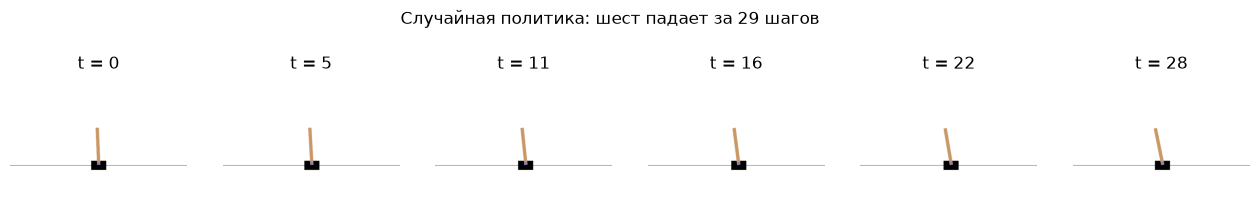

In [9]:
# Эпизод со случайной политикой: сохраним кадры.
cartpole = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = cartpole.reset(seed=1)
frames = []
for t in range(60):
    frames.append(cartpole.render())
    obs, r, terminated, truncated, _ = cartpole.step(cartpole.action_space.sample())
    if terminated or truncated:
        break
cartpole.close()

idx = np.linspace(0, len(frames) - 1, 6).astype(int)
fig, axes = plt.subplots(1, 6, figsize=(16, 2.6))
for ax, i in zip(axes, idx):
    ax.imshow(frames[i])
    ax.set_title(f"t = {i}")
    ax.axis("off")
plt.suptitle(f"Случайная политика: шест падает за {len(frames)} шагов")
plt.show()

Случайная политика держит шест около 20 шагов. Напишем политику руками: если шест падает вправо (угловая скорость положительная), толкаем тележку вправо, и наоборот. Здесь политика — уже не таблица, а **правило**: состояний-векторов бесконечно много, таблицу по ним не составишь.

In [10]:
def random_policy(obs):
    return np.random.randint(2)

def heuristic_policy(obs):
    x, x_dot, theta, theta_dot = obs
    return int(theta_dot > 0)   # толкаем в ту сторону, куда падает шест

def run_episodes(policy, n_episodes=50, seed=0):
    cartpole = gym.make("CartPole-v1")
    returns = []
    for ep in range(n_episodes):
        obs, _ = cartpole.reset(seed=seed + ep)
        total = 0
        while True:
            obs, r, terminated, truncated, _ = cartpole.step(policy(obs))
            total += r
            if terminated or truncated:
                break
        returns.append(total)
    cartpole.close()
    return np.array(returns)

np.random.seed(0)
for name, policy in [("случайная", random_policy), ("эвристика", heuristic_policy)]:
    G = run_episodes(policy)
    print(f"{name:10s}: средняя суммарная награда {G.mean():6.1f} ± {G.std():5.1f} (максимум 500)")

случайная : средняя суммарная награда   18.5 ±   7.3 (максимум 500)
эвристика : средняя суммарная награда  194.0 ±  39.6 (максимум 500)


Эвристика в 10 раз лучше случайной, но её придумал человек, зная физику задачи, и до максимума она не дотягивает. Для Atari, шахмат или гуманоида с 17 суставами такое правило руками не напишешь.

**Задача RL** — получить политику не хуже эвристики, **не зная** устройства среды, только из опыта взаимодействия. Первый такой алгоритм увидим сегодня в разделе 12, а на неделе 6 нейросеть будет стабильно держать 500 шагов.

**⏱ Если есть время**: посмотреть среду посложнее — LunarLander (нужен `box2d`).

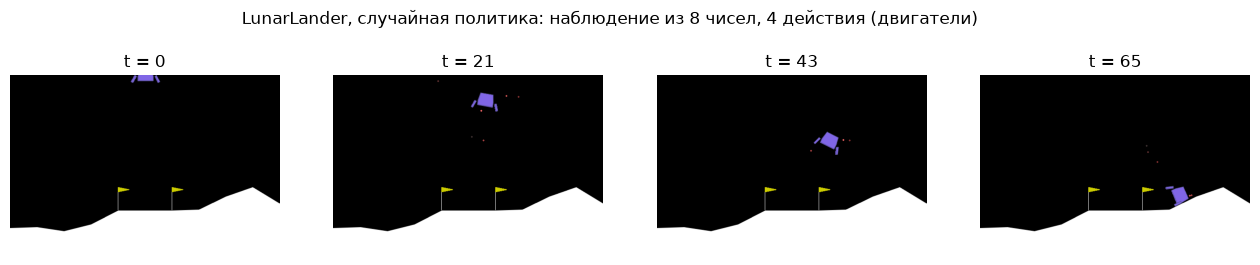

In [11]:
try:
    cartpole = gym.make("LunarLander-v3", render_mode="rgb_array")
    obs, _ = cartpole.reset(seed=0)
    frames = []
    for t in range(120):
        frames.append(cartpole.render())
        obs, r, terminated, truncated, _ = cartpole.step(cartpole.action_space.sample())
        if terminated or truncated:
            break
    cartpole.close()
    idx = np.linspace(0, len(frames) - 1, 4).astype(int)
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
    for ax, i in zip(axes, idx):
        ax.imshow(frames[i]); ax.set_title(f"t = {i}"); ax.axis("off")
    plt.suptitle("LunarLander, случайная политика: наблюдение из 8 чисел, 4 действия (двигатели)")
    plt.show()
except Exception as e:  # box2d не установлен или не собрался
    print("LunarLander недоступен:", type(e).__name__, "-", str(e)[:120])
    print("Гифку можно посмотреть в документации: https://gymnasium.farama.org/environments/box2d/lunar_lander/")

### Тележка на горке: хорошая и плохая политика

Среда одна, агент один, награда одна — меняется только **политика**. Посмотрим на двух «агентов», написанных руками:

* **«газ вправо»** — жадная к цели политика: цель справа, значит, всё время газуем вправо;
* **«раскачка»** — газуем туда, куда уже едем: `вправо`, если скорость положительна, и `влево`, если отрицательна.

«газ вправо»  : шагов 200, максимальная высота x = -0.30, доехал до флажка: НЕТ
«раскачка»    : шагов 101, максимальная высота x = +0.51, доехал до флажка: да


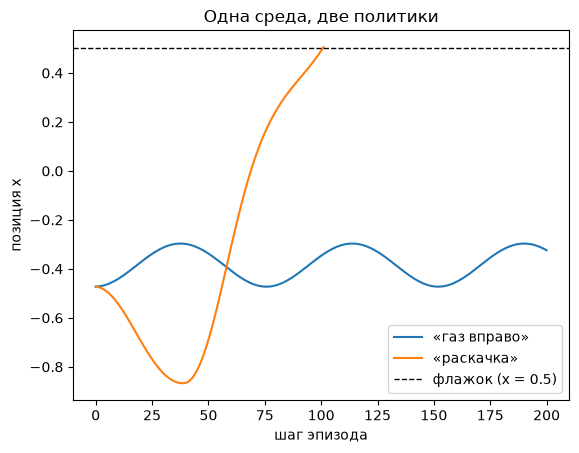

In [12]:
def run_mountain_car(policy, seed=0, max_steps=200, every=4):
    """Один эпизод MountainCar. Возвращает кадры (каждый every-й), позиции и флаг успеха."""
    env = gym.make("MountainCar-v0", render_mode="rgb_array", max_episode_steps=max_steps)
    obs, _ = env.reset(seed=seed)
    frames, xs, t, terminated = [], [obs[0]], 0, False
    while True:
        if t % every == 0:
            frames.append(env.render())
        obs, r, terminated, truncated, _ = env.step(policy(obs))
        xs.append(obs[0]); t += 1
        if terminated or truncated:
            break
    env.close()
    return frames, np.array(xs), terminated

gas_right   = lambda obs: 2                      # всегда газ вправо
swing       = lambda obs: 2 if obs[1] > 0 else 0  # газ в ту сторону, куда уже едем

for name, policy in [("«газ вправо»", gas_right), ("«раскачка»", swing)]:
    frames, xs, ok = run_mountain_car(policy)
    print(f"{name:14s}: шагов {len(xs)-1:3d}, максимальная высота x = {xs.max():+.2f}, "
          f"доехал до флажка: {'да' if ok else 'НЕТ'}")
    plt.plot(xs, label=name)

plt.axhline(0.5, color="k", ls="--", lw=1, label="флажок (x = 0.5)")
plt.xlabel("шаг эпизода"); plt.ylabel("позиция x"); plt.legend()
plt.title("Одна среда, две политики"); plt.show()

In [13]:
frames_bad, _, _ = run_mountain_car(gas_right)
frames_good, _, _ = run_mountain_car(swing)
display(show_frames(frames_bad, "Плохая политика: газ вправо, машинка не выезжает"))
display(show_frames(frames_good, "Хорошая политика: раскачка, машинка доезжает"))

Разница между «доехал» и «не доехал» — не в среде и не в награде, а только в политике. При этом «плохая» политика выглядит совершенно разумно: она всё время едет **к цели**. Проигрывает она потому, что жадничает — не готова временно ехать в противоположную сторону ради выигрыша потом. Ровно этому — терпеть сейчас ради суммарной награды — и учится RL-агент.

Обратите внимание и на другое: политику «раскачка» придумал человек, глядя на физику задачи. В разделе 12 такую же (и лучше) политику найдёт алгоритм, который про горки, тележки и энергию не знает ничего.

Итог трёх демо: **состояние** может быть номером клетки или вектором чисел, **политика** — таблицей или правилом, а качество политики видно только по тому, чем заканчиваются эпизоды. Теперь — немного формализма, без которого дальше не обойтись.

## 8. Марковское свойство и MDP

Чтобы про среду можно было что-то доказывать и программировать, нужна её математическая модель. Она называется **марковский процесс принятия решений** (MDP) и строится в два шага.

### 8.1 Марковское свойство и марковские цепи

Состояние среды в моменты времени $S_0, S_1, S_2, \ldots$ — **случайный процесс**: погода по дням, курс акции по минутам, клетка, в которой стоит агент. В общем случае $S_{t+1}$ может зависеть от всей истории. **Марковское свойство** — упрощение, на котором держится весь RL:

$$
\mathbb{P}[S_{t+1} \mid S_t] = \mathbb{P}[S_{t+1} \mid S_0, S_1, \ldots, S_t].
$$

«Будущее зависит от прошлого только через настоящее.» Шахматная позиция марковская: чтобы выбрать ход, неважно, как фигуры пришли на свои места. Одна фотография летящего мяча — нет: по ней не видно, куда он летит, нужна ещё скорость. Поэтому в CartPole в состояние включают скорости, а в Atari складывают четыре последних кадра. Если состояние выбрано правильно, вся полезная история уже в нём.

**Марковская цепь** — состояния плюс матрица переходов $P$, где $P_{ss'} = \mathbb{P}[S_{t+1} = s' \mid S_t = s]$; строки суммируются в единицу. Пример — день студента:

![chain](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/markov_chain.png)

In [14]:
day = ["Лекция", "Соцсети", "Сон", "Экзамен сдан"]
P = np.array([[0.0, 0.5, 0.2, 0.3],      # из Лекции
              [0.3, 0.0, 0.7, 0.0],      # из Соцсетей
              [1.0, 0.0, 0.0, 0.0],      # из Сна
              [0.0, 0.0, 0.0, 1.0]])     # Экзамен сдан — поглощающее состояние, из него не выйти
assert np.allclose(P.sum(axis=1), 1)

rng = np.random.default_rng(0)
for _ in range(3):                                            # три случайные истории: из s прыгаем в s' с вероятностью P[s, s']
    s, path = 0, [day[0]]
    while s != 3 and len(path) < 10:
        s = rng.choice(4, p=P[s]); path.append(day[s])
    print(" -> ".join(path))

p0 = np.array([1.0, 0.0, 0.0, 0.0])                            # старт: точно в Лекции
for n in [1, 5, 20]:                                           # распределение через n шагов: p0 @ P^n
    p_n = p0 @ np.linalg.matrix_power(P, n)
    print(f"через {n:2d} шагов: " + ", ".join(f"{name} {p:.2f}" for name, p in zip(day, p_n)))

Лекция -> Сон -> Лекция -> Соцсети -> Лекция -> Экзамен сдан
Лекция -> Экзамен сдан
Лекция -> Сон -> Лекция -> Сон -> Лекция -> Экзамен сдан
через  1 шагов: Лекция 0.00, Соцсети 0.50, Сон 0.20, Экзамен сдан 0.30
через  5 шагов: Лекция 0.24, Соцсети 0.06, Сон 0.15, Экзамен сдан 0.55
через 20 шагов: Лекция 0.02, Соцсети 0.01, Сон 0.02, Экзамен сдан 0.95


Матрица переходов отвечает на любой вопрос о будущем цепи, а историю хранить не нужно — в этом вся польза марковского свойства.

### 8.2 MDP: добавляем действия

Пока состояния менялись сами. Дадим агенту возможность **влиять** на переходы. **MDP** — кортеж $\langle \mathcal{S}, \mathcal{A}, P, R, \gamma \rangle$: состояния, действия, вероятности переходов $P(s' \mid s, a)$ — теперь они зависят от действия, — ожидаемая награда $R(s, a)$ и коэффициент дисконтирования $\gamma$ из раздела 5. Траектория порождается так: агент в $S_0$ выбирает $A_0 \sim \pi(\cdot \mid S_0)$, получает $R_0$ и переходит в $S_1 \sim P(\cdot \mid S_0, A_0)$, и так далее.

Наше озеро — тоже MDP, и его таблица переходов буквально лежит внутри среды. Пока лёд не скользкий, все вероятности равны 1. Включим скольжение: теперь агент идёт туда, куда хотел, лишь с вероятностью 1/3, а с вероятностью 2/3 его сносит вбок. Вот она — **случайность среды**.

In [15]:
slippery = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
print("скользкий лёд, из клетки 6 действие ↓:")
for prob, next_state, reward, terminated in slippery.unwrapped.P[6][1]:     # P[состояние][действие]
    print(f"  с вероятностью {prob:.2f} -> клетка {next_state:2d}, награда {reward}, terminated={terminated}")

скользкий лёд, из клетки 6 действие ↓:
  с вероятностью 0.33 -> клетка  5, награда 0, terminated=True
  с вероятностью 0.33 -> клетка 10, награда 0, terminated=False
  с вероятностью 0.33 -> клетка  7, награда 0, terminated=True


Из клетки 6 шаг вниз в двух случаях из трёх заканчивается в проруби. Лучше идти влево или вправо — тогда опасен только один исход из трёх, — а у края озера ещё лучше шагать **в стену**: шаг в стену оставляет на месте, и провалиться нельзя вовсе. Такие неочевидные решения и должен находить алгоритм, а не человек.

Полезное наблюдение: **если политику зафиксировать, MDP превращается в обычную марковскую цепь** — действия усредняются с весами $\pi(a \mid s)$. Поэтому оценивать заданную политику проще, чем искать лучшую, и именно с оценки мы начнём в разделе 11.

![gridworld](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/mdp_gridworld.png)

Этого определения нам хватит на сегодня. Важно другое: алгоритму, который мы напишем, таблица $P$ **не нужна** — он будет только играть и смотреть на результат. В реальных задачах (робот, биржа) этой таблицы никто и не выдаст.

## 11. Награда — это формулировка задачи, и её легко испортить

Агент оптимизирует ровно то, что написано в награде, а не то, что вы имели в виду. Классический пример — [CoastRunners](https://openai.com/index/faulty-reward-functions/): агента-лодку обучали на игровые очки, и вместо прохождения трассы он нашёл лагуну, где можно бесконечно крутиться, собирать бонусы и врезаться в стены. Очков больше, чем у любого честного игрока. Это называется **reward hacking**; обзор с десятками примеров есть у [Lilian Weng](https://lilianweng.github.io/posts/2024-11-28-reward-hacking/).

> **Факт.** В экспериментах OpenAI с игрой в прятки агенты нашли ошибки в физическом движке: научились «сёрфить» на коробке и выкидывать предметы за пределы карты. Никто не закладывал такого поведения — оно просто приносило больше награды.

Практическое правило: награда должна описывать *что* нужно получить, а не *как* это делать. Если написать в награду «держи угол шеста маленьким», агент найдёт способ держать угол маленьким, необязательно тот, который вы ожидали.

## 10. Исследование и использование

Есть дилемма, которой нет ни в supervised, ни в unsupervised learning и которая всплывёт в каждом алгоритме курса.

* **Использование (exploitation)** — делать то, что по накопленному опыту кажется лучшим. Выгодно **сейчас**.
* **Исследование (exploration)** — пробовать то, про что мы мало знаем. Стоит награды сейчас, окупается **потом**.

Бытовой пример — обед: пойти в проверенное кафе или попробовать новое? Если после одного удачного обеда всегда ходить в одно место, мы никогда не узнаем, что через дорогу лучше. Наша собственная политика закрыла нам доступ к этим данным.

На озере то же самое видно за одну ячейку. Возьмём политику, которая всегда идёт вправо, и сравним с равномерной.

In [16]:
always_right = np.zeros((n_states, n_actions)); always_right[:, 2] = 1.0      # детерминированная: всегда →

rng = np.random.default_rng(0)
for name, policy in [("всегда →   ", always_right), ("равномерная", uniform_policy)]:
    sessions = [run_session(env, policy, rng) for _ in range(500)]
    success = np.mean([sum(r) > 0 for *_, r in sessions])
    length = np.mean([len(a) for _, a, _ in sessions])
    print(f"{name}: успешных эпизодов {success:5.1%}, средняя длина эпизода {length:3.0f} шагов")

всегда →   : успешных эпизодов  0.0%, средняя длина эпизода 100 шагов
равномерная: успешных эпизодов  3.2%, средняя длина эпизода   8 шагов


Политика «всегда вправо» упирается в стену в клетке 3 и стоит там до конца лимита шагов — все 500 раз одинаково. Она не просто плохая: её эпизоды не несут **никакой новой информации**, по ним нельзя понять, что делать иначе. Равномерная политика доходит до цели редко, в паре процентов случаев, — но эти несколько эпизодов и есть материал, из которого можно учиться.

Отсюда правило, которым мы будем пользоваться весь курс: **политика во время обучения должна оставаться случайной**. Как именно дозировать случайность — тема следующих недель; алгоритм из раздела 12 работает ровно потому, что его политика стохастическая.

## 11. Как измерить политику: Монте-Карло и ценность состояния

### 11.1 Оценка политики методом Монте-Карло

Прежде чем улучшать политику, надо научиться её **измерять**. Качество политики $\pi$ — это ожидаемый return:

$$
J(\pi) = \mathbb{E}_{\pi}[G].
$$

Взять и посчитать это матожидание мы не можем: чтобы усреднить по всем возможным траекториям, нужны $P(s' \mid s, a)$ и $R(s, a)$ — модель среды. В разделе 8 мы подсмотрели таблицу переходов озера, но в реальной задаче её никто не выдаст. Зато агент умеет другое — **играть**. А по закону больших чисел среднее по сыгранным эпизодам сходится к матожиданию:

$$
J(\pi) \;\approx\; \frac{1}{K} \sum_{k=1}^{K} G(\tau_k), \qquad \tau_k \sim \pi .
$$

Это и есть **метод Монте-Карло**, он же **policy evaluation** в простейшем виде: хочешь узнать, хороша ли политика — сыграй ей много раз и усредни. Модель среды не нужна, нужна только возможность взаимодействовать; точность растёт как $1/\sqrt{K}$.

> Оценка политики по сыгранным эпизодам — базовый кирпич всего курса. На неделе 3 из него вырастут Monte-Carlo- и TD-обучение, а сегодня он понадобится как **шаг 1** первого алгоритма.

Оценим равномерную политику по 500 эпизодам.

оценка J(π) по 500 эпизодам: 0.012
успешных эпизодов: 10 из 500, их returns: [0.77 0.66 0.66 0.63 0.63 0.6  0.54 0.46 0.44 0.36]


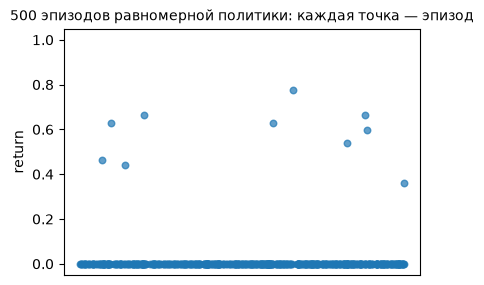

In [17]:
rng = np.random.default_rng(0)
sessions = [run_session(env, uniform_policy, rng) for _ in range(500)]
returns = np.array([discounted_return(r) for *_, r in sessions])

print(f"оценка J(π) по 500 эпизодам: {returns.mean():.3f}")
print(f"успешных эпизодов: {(returns > 0).sum()} из 500, их returns: {np.round(np.sort(returns[returns > 0])[::-1], 2)}")
plot_returns(returns, title="500 эпизодов равномерной политики: каждая точка — эпизод"); plt.show()

Картина обескураживающая, но именно она — постановка задачи для раздела 12. Обратите внимание на две вещи.

* **Оценка работает.** Не зная ни $P$, ни $R$, мы получили число, которым можно сравнивать политики между собой. Подставим вместо равномерной любую другую — и сразу увидим, лучше она или хуже.
* **Сигнал редкий.** Почти все точки лежат на нуле, вся полезная информация сидит в десятке удачных эпизодов. Значит, улучшать политику придётся, вытаскивая её именно из этого десятка.

### 11.2 Ценность состояния: интуиция

Мы измерили политику **в целом**, одним числом. Но те же эпизоды позволяют ответить на более тонкий вопрос: **насколько хорошо оказаться в конкретной клетке?** Достаточно усреднять return не от старта, а от момента первого попадания в эту клетку. Это число называется **ценностью состояния**:

$$
V^\pi(s) = \mathbb{E}_\pi\big[G_t \mid S_t = s\big] \;\approx\; \text{средний return эпизодов, считая от первого попадания в } s .
$$

Ценность зависит и от клетки, и от политики: одна и та же клетка ценна для умного агента и почти бесполезна для того, кто дальше блуждает наугад. Считается за восемь строк.

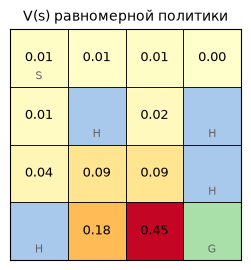

In [18]:
def estimate_values(sessions, n_states, gamma=GAMMA):
    """V(s) ≈ средний return эпизода, считая от первого попадания в клетку s."""
    total, count = np.zeros(n_states), np.zeros(n_states)
    for states, actions, rewards in sessions:
        for t, s in enumerate(states[:-1]):
            if s not in states[:t]:                              # учитываем только первое посещение
                total[s] += discounted_return(rewards[t:], gamma); count[s] += 1
    return np.divide(total, count, out=np.full(n_states, np.nan), where=count > 0)   # NaN — клетку не посещали

rng = np.random.default_rng(1)
sessions_uniform = [run_session(env, uniform_policy, rng) for _ in range(3000)]    # побольше эпизодов, чтобы оценка не шумела
V_uniform = estimate_values(sessions_uniform, n_states)
plot_values(V_uniform, desc, title="V(s) равномерной политики"); plt.show()

Карта читается сама: чем ближе к цели, тем клетка ценнее, у старта ценность почти ноль (дойти оттуда наугад — редкая удача). У прорубей и у самой цели ценности нет: это терминальные состояния, будущего у них нет, а награда за вход в цель уже учтена в ценности соседней клетки.

Точно так же можно спросить, насколько хорошо в клетке $s$ сделать конкретное действие $a$. Это **ценность действия** $Q^\pi(s, a)$. Посчитаем её для клетки 14, слева от цели.

In [19]:
Q14, visits = np.zeros(n_actions), np.zeros(n_actions)
for states, actions, rewards in sessions_uniform:
    for t, (s, a) in enumerate(zip(states[:-1], actions)):
        if s == 14 and 14 not in states[:t]:                       # первое попадание в клетку 14
            Q14[a] += discounted_return(rewards[t:]); visits[a] += 1
            break
for a in range(n_actions):
    print(f"Q(14, {ARROWS[a]}) ≈ {Q14[a] / visits[a]:.2f}   (по {int(visits[a])} эпизодам)")

Q(14, ←) ≈ 0.22   (по 30 эпизодам)
Q(14, ↓) ≈ 0.50   (по 18 эпизодам)
Q(14, →) ≈ 1.00   (по 27 эпизодам)
Q(14, ↑) ≈ 0.11   (по 25 эпизодам)


Шаг вправо из клетки 14 стоит ровно 1: это вход в цель. Остальные действия хуже, и цифры говорят, **насколько**. Будь у нас такая таблица $Q$ для всех клеток, политика получалась бы даром: в каждой клетке выбирай действие с наибольшей ценностью. Но собирать эти числа, играя тысячи эпизодов, дорого. На неделе 3 мы увидим, что ценности соседних клеток связаны простым уравнением (уравнением Беллмана) и их можно вычислять друг через друга. Сегодня пойдём другим путём: будем улучшать саму политику, глядя на целые эпизоды.

## 12. Первый алгоритм: метод Cross-Entropy

Оценивать политику мы научились. Осталось её **улучшать**.

Казалось бы, можно перебрать политики и выбрать лучшую. Посчитаем: на озере 4×4 состояний 16, действий 4, значит, детерминированных политик $4^{16} \approx 4 \cdot 10^9$. На поле 8×8 — уже $4^{64} \approx 3 \cdot 10^{38}$. Перебор безнадёжен, и это ещё простейшие среды. Политику нужно не перебирать, а **постепенно улучшать по собственному опыту**.

### 12.1 Идея

Представьте, что вы учитесь готовить блюдо без рецепта. Вы готовите его 100 раз, каждый раз чуть по-разному, отбираете 20 самых удачных попыток, смотрите, что в них общего, и в следующей сотне чаще делаете именно так. Через несколько кругов получается рецепт. Ровно это и делает метод Cross-Entropy (CEM):

![cem](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/cem_loop.png)

1. **Сыграть** $K$ эпизодов текущей политикой — это оценка Монте-Карло из раздела 11.
2. **Отобрать элиту** — эпизоды с return выше порога.
3. **Подстроить политику** — сделать так, чтобы действия из элитных эпизодов выбирались чаще.

И повторять. Алгоритм ничего не знает про устройство среды — ни $P$, ни $R$ ему не нужны, он только играет и смотрит на результат (**model-free**). Пройдём все три шага руками на озере, с картинкой на каждом шаге, а потом соберём их в цикл.

### 12.2 Шаг 1. Сыграть

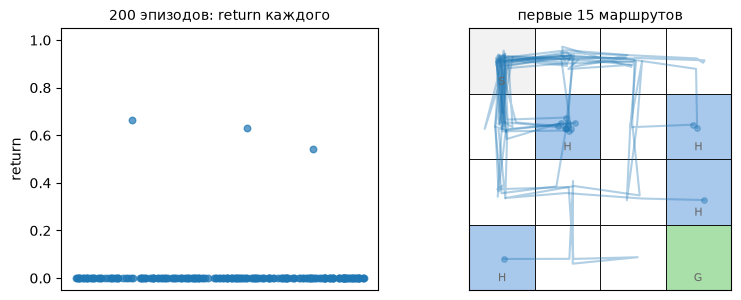

In [20]:
rng = np.random.default_rng(0)
policy = uniform_policy.copy()

sessions = [run_session(env, policy, rng) for _ in range(200)]
returns = np.array([discounted_return(r) for *_, r in sessions])

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
plot_returns(returns, ax=axes[0], title="200 эпизодов: return каждого")
draw_paths(sessions[:15], desc, ax=axes[1], title="первые 15 маршрутов")
plt.show()

Слева — то, что видит алгоритм: облако из 200 точек, почти все на нуле и несколько выше. Справа — как это выглядит на карте: случайные блуждания, которые чаще всего заканчиваются в проруби.

### 12.3 Шаг 2. Отобрать элиту

Порог не задаём руками, а берём **квантиль** уровня $q$ от всех returns: при $q = 0.7$ хотим оставить лучшие 30%. Посчитаем.

In [21]:
q = 0.7
threshold = np.quantile(returns, q)
print(f"квантиль уровня {q}: порог = {threshold}")
print(f"эпизодов с return >= порога: {(returns >= threshold).sum()} из 200")

квантиль уровня 0.7: порог = 0.0
эпизодов с return >= порога: 200 из 200


Порог оказался **нулём**, и условие «не хуже порога» проходят все 200 эпизодов, включая провальные: когда 97% точек лежат на нуле, любой квантиль ниже 0.97 — тоже ноль. Учиться на «всех» — значит скопировать случайное блуждание, то есть не сдвинуться с места.

Поэтому нужно второе условие: в элиту берём эпизоды **не хуже порога и строго лучше самого плохого**. На первых итерациях именно оно — настоящий фильтр: остаются ровно те несколько эпизодов, которые чем-то отличились. А если не отличился никто, элита пуста, и политика честно остаётся прежней.

в элите 3 эпизодов, их returns: [0.66 0.63 0.54]


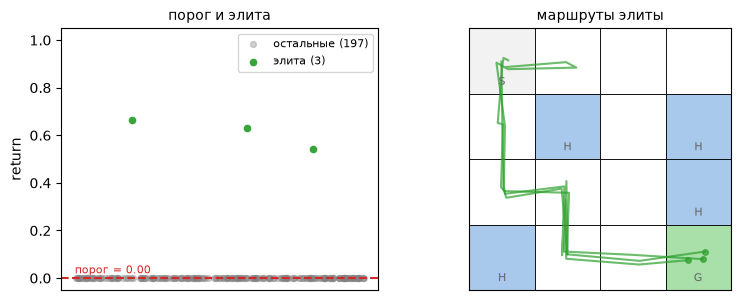

In [22]:
is_elite = (returns >= threshold) & (returns > returns.min())
elite = [sessions[i] for i in np.flatnonzero(is_elite)]
print(f"в элите {len(elite)} эпизодов, их returns: {np.round(returns[is_elite], 2)}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
plot_returns(returns, threshold, is_elite, ax=axes[0], title="порог и элита")
draw_paths(elite, desc, ax=axes[1], title="маршруты элиты", color="C2", alpha=0.7)
plt.show()

На карте остались только маршруты, дошедшие до цели. Они не идеальны — петляют, заходят в тупики, — но в них уже есть то, чего нет в остальных: **направление**.

Почему квантиль, а не фиксированный порог: планка **сама растёт** вместе с политикой. Сегодня элита — «хоть как-то дошёл», через несколько итераций — «дошёл за 6 шагов», потому что благодаря $\gamma$ короткий путь даёт больший return. Параметр $q$ — доля отбрасываемых эпизодов; обычно берут от 0.5 до 0.9.

### 12.4 Шаг 3. Подстроить политику

Новая политика — просто **частоты действий в элитных эпизодах**:

$$
\pi_{\text{new}}(a \mid s) = \frac{\#\{\text{в элите в состоянии } s \text{ сделали } a\}}{\#\{\text{в элите побывали в } s\}} .
$$

Клетки, куда элита не заходила, оставляем как были. Посчитаем и посмотрим, что стало со стартовой клеткой и со всей картой.

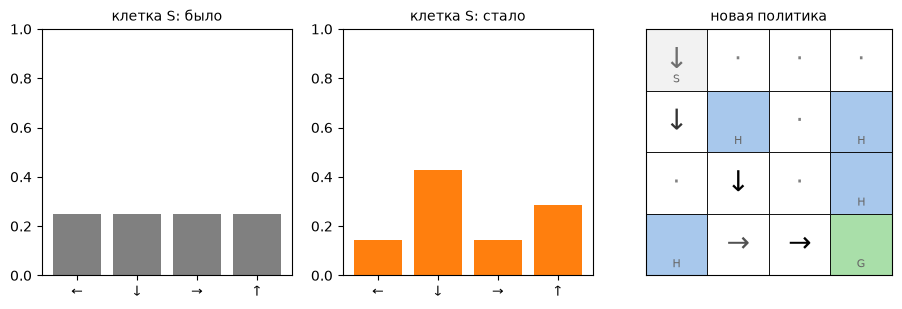

счётчики для клетки S: [1. 3. 1. 2.] -> новая строка политики: [0.14 0.43 0.14 0.29]


In [23]:
counts = np.zeros((n_states, n_actions))
for states, actions, rewards in elite:
    for s, a in zip(states, actions):
        counts[s, a] += 1                                        # сколько раз элита делала a в s

new_policy = policy.copy()
seen = counts.sum(axis=1) > 0                                    # клетки, куда элита заходила
new_policy[seen] = counts[seen] / counts[seen].sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, row, title, color in [(axes[0], policy[0], "клетка S: было", "grey"),
                              (axes[1], new_policy[0], "клетка S: стало", "C1")]:
    ax.bar(list(ARROWS), row, color=color); ax.set_ylim(0, 1); ax.set_title(title, fontsize=10)
draw_policy(new_policy, desc, ax=axes[2], title="новая политика")
plt.show()
print("счётчики для клетки S:", counts[0], "-> новая строка политики:", np.round(new_policy[0], 2))

Одна итерация — и в стартовой клетке появилось предпочтение идти вниз, а на карте проступил маршрут. Стрелка — самое вероятное действие, насыщенность — насколько политика в нём уверена; точками помечены клетки, где вероятности так и остались равными: элита туда не заходила, «выученного действия» там нет.

Заодно видна опасность этого шага. Действие, ни разу не встретившееся в элите, получает вероятность **ровно ноль**, и агент больше никогда его не попробует, а значит, никогда не узнает, что бы из него вышло (раздел 10 в чистом виде). Два стандартных лекарства, оба — по одному параметру:

* **сглаживание по Лапласу**: к счётчикам добавляем $\lambda$, $\pi(a \mid s) = \dfrac{n(s,a) + \lambda}{n(s) + \lambda\,|\mathcal{A}|}$ — ни одно действие не обнуляется;
* **смешивание со старой политикой**: $\pi \leftarrow \alpha\,\pi_{\text{new}} + (1 - \alpha)\,\pi_{\text{old}}$ — политика меняется плавно, как при маленьком learning rate.

### 12.5 Собираем в цикл

Оформим шаги 2 и 3 в две короткие функции (лекарства — параметры, по умолчанию выключены), а цикл — в третью. Весь алгоритм — около тридцати строк, и половину из них мы уже написали выше.

In [24]:
def select_elite(sessions, scores, q=0.7):
    """Элита: эпизоды с оценкой не ниже квантиля уровня q и строго выше самой плохой."""
    scores = np.asarray(scores)
    threshold = np.quantile(scores, q)
    keep = (scores >= threshold) & (scores > scores.min())
    return [sessions[i] for i in np.flatnonzero(keep)]

def update_policy(policy, elite, laplace=0.0, mix=1.0):
    """Новая политика — частоты действий элиты. laplace — сглаживание, mix — доля новой политики в смеси."""
    counts = np.full(policy.shape, laplace)
    for states, actions, *_ in elite:
        for s, a in zip(states, actions):
            counts[s, a] += 1
    new_policy = policy.copy()
    seen = counts.sum(axis=1) > 0                                # строки, куда элита заходила
    new_policy[seen] = counts[seen] / counts[seen].sum(axis=1, keepdims=True)
    return mix * new_policy + (1 - mix) * policy

In [25]:
def cross_entropy_method(env, n_iter=15, n_sessions=200, q=0.7, laplace=0.0, mix=1.0, seed=0):
    rng = np.random.default_rng(seed)
    policy = np.ones((env.observation_space.n, env.action_space.n)) / env.action_space.n
    log = {"policies": [], "success": [], "return": []}
    for _ in range(n_iter):
        sessions = [run_session(env, policy, rng) for _ in range(n_sessions)]     # 1. сыграть
        returns = [discounted_return(r) for *_, r in sessions]
        elite = select_elite(sessions, returns, q)                                # 2. отобрать элиту
        log["policies"].append(policy); log["return"].append(np.mean(returns))
        log["success"].append(np.mean([G > 0 for G in returns]))
        policy = update_policy(policy, elite, laplace, mix)                       # 3. подстроить политику
    return policy, log

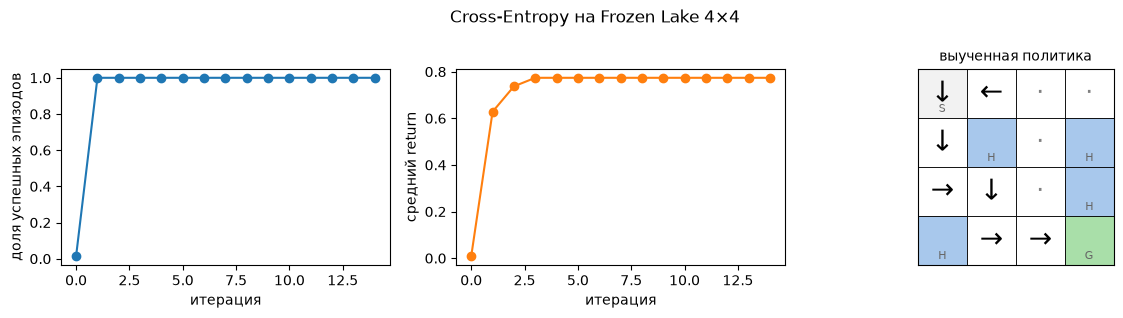

In [26]:
policy_lake, log = cross_entropy_method(env, n_iter=15, n_sessions=200, q=0.7)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].plot(log["success"], marker="o"); axes[0].set_xlabel("итерация"); axes[0].set_ylabel("доля успешных эпизодов")
axes[1].plot(log["return"], marker="o", color="C1"); axes[1].set_xlabel("итерация"); axes[1].set_ylabel("средний return")
draw_policy(policy_lake, desc, ax=axes[2], title="выученная политика")
plt.suptitle("Cross-Entropy на Frozen Lake 4×4"); plt.tight_layout(); plt.show()

Обучение заняло **одну итерацию**: первые же удачные траектории попали в элиту, алгоритм их скопировал, и дальше все 200 эпизодов стали успешными. Средний return при этом рос ещё две итерации: планка поднималась, элита отбирала всё более короткие маршруты, пока не остался кратчайший ($0.95^5 = 0.77$). Потом худший return сравнялся с лучшим, элита опустела, и политика застыла.

Так быстро — потому что озеро крошечное и не скользкое. Чтобы увидеть обучение как процесс, включим лекарства из 12.4: политика будет меняться плавно, и каждый кадр анимации — одна итерация.

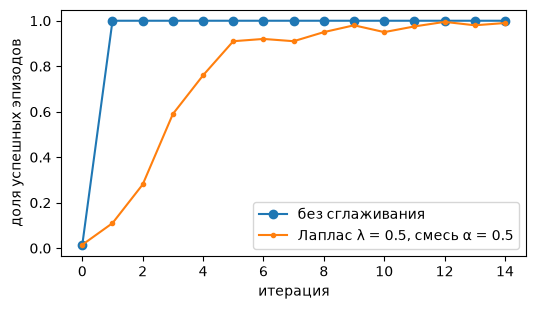

In [27]:
policy_smooth, log_smooth = cross_entropy_method(env, n_iter=15, n_sessions=200, q=0.7, laplace=0.5, mix=0.5)

plt.figure(figsize=(6, 3.2))
plt.plot(log["success"], marker="o", label="без сглаживания")
plt.plot(log_smooth["success"], marker=".", label="Лаплас λ = 0.5, смесь α = 0.5")
plt.xlabel("итерация"); plt.ylabel("доля успешных эпизодов"); plt.legend(); plt.show()

animate_policy(log_smooth["policies"], log_smooth["success"], desc)

Из полного хаоса постепенно проступает маршрут в обход прорубей, и растёт уверенность в каждой клетке. Это и есть цикл «сыграть — отобрать — подстроить», прокрученный пятнадцать раз.

Вернёмся к тепловой карте из раздела 11 и посчитаем ценность клеток для выученной политики — тем же кодом.

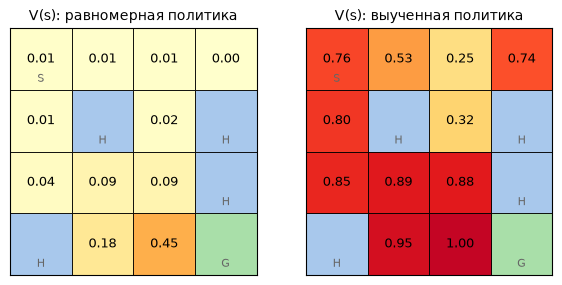

In [28]:
rng = np.random.default_rng(1)
sessions_learned = [run_session(env, policy_smooth, rng) for _ in range(3000)]
V_learned = estimate_values(sessions_learned, n_states)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.4))
plot_values(V_uniform, desc, ax=axes[0], title="V(s): равномерная политика", vmax=1)
plot_values(V_learned, desc, ax=axes[1], title="V(s): выученная политика", vmax=1)
plt.show()

На общей шкале видно, что произошло: ценность выросла **везде**, а у старта — с 0.01 почти до 0.77, то есть до return кратчайшего пути. Если какая-то клетка перестаёт посещаться, вместо числа появляется прочерк: оценить её нельзя, агент знает только то, что посещает.

### 12.6 Почему «кросс-энтропия»

Шаг 3 выглядит как подсчёт палочек, но за ним стоит оптимизационная задача: мы ищем политику, при которой элитные действия наиболее вероятны, то есть максимизируем **логарифм правдоподобия** элитных пар $(s, a)$:

$$
\max_{\pi} \sum_{(s, a) \in \text{элита}} \log \pi(a \mid s)
\quad \Longleftrightarrow \quad
\min_{\pi} \ \underbrace{-\sum_{s} \sum_{a} p_{\text{элита}}(a \mid s) \log \pi(a \mid s)}_{\text{кросс-энтропия } H(p_{\text{элита}},\ \pi)} .
$$

Мы минимизируем **кросс-энтропию** между распределением действий в элите и нашей политикой — отсюда название; для таблицы решение выписывается явно, и это те самые частоты. Отсюда главная мысль раздела и мостик к разделу 3:

> На каждой итерации CEM превращает задачу RL в обычную задачу **обучения с учителем**: объекты — состояния из элитных эпизодов, правильные ответы — действия, которые агент в них сделал, функция потерь — кросс-энтропия. Разница с supervised learning только в том, что разметку никто не давал: агент **сгенерировал её себе сам**, отобрав свои же лучшие попытки.

Это же объясняет, как метод масштабируется: когда состояний слишком много для таблицы (кадры Atari, координаты робота), таблицу заменяют нейросетью $\pi_\theta(a \mid s)$, а шаг 3 — градиентным спуском по той же кросс-энтропии (`nn.CrossEntropyLoss` в PyTorch: элитные состояния — батч, элитные действия — метки классов). Это deep Cross-Entropy Method, неделя 5.

### 12.7 Что может пойти не так

**1. Мало эпизодов на итерацию.** Если среди сыгранных эпизодов ни один не дошёл до цели, все returns одинаковы, элита пуста, политика не двигается — и так может продолжаться сколь угодно долго. Метод живёт за счёт случайных успехов, а чем больше среда, тем они реже.

**2. Схлопывание политики.** Без сглаживания одна удачная траектория может «выключить» все альтернативы, и алгоритм застрянет на первом найденном решении, даже если рядом есть куда лучше.

Посмотрим на обе болезни в числах.

In [29]:
# Болезнь 1: по 5 эпизодов на итерацию вместо 200, десять запусков с разными сидами.
finals = [cross_entropy_method(env, n_iter=5, n_sessions=5, seed=s)[1]["success"][-1] for s in range(10)]
print("по 5 эпизодов на итерацию, доля успехов в конце:", " ".join(f"{f:4.0%}" for f in finals))
p = (returns > 0).mean()                                   # доля успехов равномерной политики (раздел 12.2)
print(f"шанс не увидеть ни одного успеха: среди 25 эпизодов — {(1 - p) ** 25:.0%}, среди 200 — {(1 - p) ** 200:.0%}")

# Болезнь 2: схлопывание. Сколько вероятностей обнулилось за три итерации?
for label, cure in [("без сглаживания          ", {}), ("Лаплас λ=0.5, смесь α=0.5", dict(laplace=0.5, mix=0.5))]:
    pol, _ = cross_entropy_method(env, n_iter=3, n_sessions=200, **cure)
    print(f"{label}: действий с нулевой вероятностью {(pol == 0).mean():.0%}")

по 5 эпизодов на итерацию, доля успехов в конце:   0% 100%  20% 100% 100%   0%   0%   0%   0%   0%
шанс не увидеть ни одного успеха: среди 25 эпизодов — 69%, среди 200 — 5%
без сглаживания          : действий с нулевой вероятностью 33%


Лаплас λ=0.5, смесь α=0.5: действий с нулевой вероятностью 0%


С пятью эпизодами на итерацию половина запусков так и остаётся на нуле: успешных траекторий не нашлось, учиться не на чем. Это не «неудачные гиперпараметры», а свойство метода. На поле 8×8 случайная политика доходит до цели реже, чем в одном эпизоде из пятисот, — прикиньте, сколько эпизодов на итерацию понадобится там (это домашнее задание).

Схлопывание тоже видно в числах: без сглаживания уже через три итерации треть всех вероятностей — нули, эти действия агент больше никогда не выберет. Со сглаживанием нулей нет вовсе.

**📖 Дома**: запустите тот же алгоритм на скользком льду (`is_slippery=True`). Это третья болезнь, **случайность среды**: в элиту попадают везучие эпизоды, а не умные, и политика учится на шуме. Спойлер: результат скачет от запуска к запуску и сильно не дотягивает до 74%, которых можно добиться на скользком озере. Что с этим делать — в домашнем задании.

### 12.8 Второй пример: тележка на горке (⏱ если есть время)

<small>Обучение здесь занимает около полуминуты — на лекции ячейки лучше прогнать заранее.</small>

Озеро — клеточный мир, где состояния уже пронумерованы. Что делать с непрерывным состоянием, как в Mountain Car (позиция и скорость)? Простейший ответ — **дискретизировать**: разбить каждую координату на несколько интервалов и считать номер клетки сетки номером состояния. Возьмём сетку $12 \times 12$: 144 состояния и 3 действия.

Но сначала — первая болезнь во всей красе.

In [30]:
NBINS = 12
LOW, HIGH = np.array([-1.2, -0.07]), np.array([0.6, 0.07])
GOAL_X = 0.5                                                   # на этой высоте стоит флажок

def encode(obs):
    """Непрерывное состояние (x, v) -> номер клетки сетки 12×12."""
    i = np.clip(((obs - LOW) / (HIGH - LOW) * NBINS).astype(int), 0, NBINS - 1)
    return int(i[0] * NBINS + i[1])

def mc_session(env, policy, rng, max_steps=200):
    """Как run_session, но состояние дискретизируется, и дополнительно запоминается максимальная высота."""
    obs, _ = env.reset(seed=int(rng.integers(1_000_000)))
    states, actions, rewards, best_x = [encode(obs)], [], [], obs[0]
    for _ in range(max_steps):
        a = int(rng.choice(3, p=policy[states[-1]]))
        obs, r, terminated, truncated, _ = env.step(a)
        states.append(encode(obs)); actions.append(a); rewards.append(r); best_x = max(best_x, obs[0])
        if terminated or truncated:
            break
    return states, actions, rewards, best_x

mc_env = gym.make("MountainCar-v0", max_episode_steps=200)
rng = np.random.default_rng(0)
uniform_mc = np.ones((NBINS * NBINS, 3)) / 3
returns_mc = [sum(r) for *_, r, _ in [mc_session(mc_env, uniform_mc, rng) for _ in range(200)]]
print(f"200 эпизодов равномерной политики: return от {min(returns_mc):.0f} до {max(returns_mc):.0f}, "
      f"разных значений всего {len(set(returns_mc))}")
print("=> все эпизоды одинаково плохи, элита пуста, CEM в таком виде не сдвинется с места.")

200 эпизодов равномерной политики: return от -200 до -200, разных значений всего 1
=> все эпизоды одинаково плохи, элита пуста, CEM в таком виде не сдвинется с места.


Это **проблема разрежённой награды**: сигнал «−1 за шаг» одинаков для всех, пока ни один эпизод случайно не доехал до флажка, а случайной политикой этого не происходит практически никогда.

Что можно сделать? Подсказать агенту промежуточную цель: отбирать элиту не по награде, а по **максимальной высоте**, которой достигла машинка. Это тот приём, о котором предупреждал раздел 9: мы вмешиваемся в постановку задачи, и делать это надо осторожно. Зато сигнал становится плотным: «эта попытка заехала выше, чем та» — и алгоритм оживает. Функции `select_elite` и `update_policy` те же самые, меняется только список оценок.

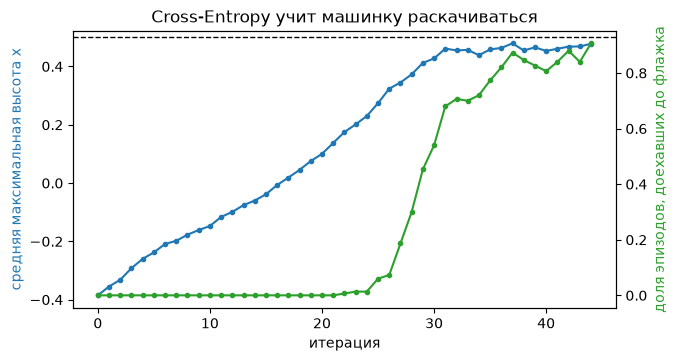

доля успешных эпизодов на последней итерации: 91%


In [31]:
def cem_mountain_car(n_iter=45, n_sessions=150, q=0.7, laplace=1.0, mix=0.6, seed=0):
    """Тот же CEM, но элита отбирается по максимальной высоте, а не по return."""
    rng = np.random.default_rng(seed)
    env = gym.make("MountainCar-v0", max_episode_steps=200)
    policy = np.ones((NBINS * NBINS, 3)) / 3
    height, success, visits = [], [], np.zeros(NBINS * NBINS)
    for _ in range(n_iter):
        sessions = [mc_session(env, policy, rng) for _ in range(n_sessions)]        # 1. сыграть
        best_x = [x for *_, x in sessions]
        elite = select_elite(sessions, best_x, q)                                    # 2. отобрать по высоте
        for states, *_ in elite:
            visits[states[:-1]] += 1
        policy = update_policy(policy, elite, laplace, mix)                          # 3. подстроить
        height.append(np.mean(best_x)); success.append(np.mean([x >= GOAL_X for x in best_x]))
    return policy, height, success, visits

policy_mc, height, success_mc, visits = cem_mountain_car()        # около полуминуты

fig, ax1 = plt.subplots(figsize=(7, 3.6))
ax1.plot(height, color="C0", marker="."); ax1.axhline(GOAL_X, color="k", ls="--", lw=1)
ax1.set_xlabel("итерация"); ax1.set_ylabel("средняя максимальная высота x", color="C0")
ax2 = ax1.twinx(); ax2.plot(success_mc, color="C2", marker="."); ax2.set_ylabel("доля эпизодов, доехавших до флажка", color="C2")
plt.title("Cross-Entropy учит машинку раскачиваться"); plt.show()
print(f"доля успешных эпизодов на последней итерации: {success_mc[-1]:.0%}")

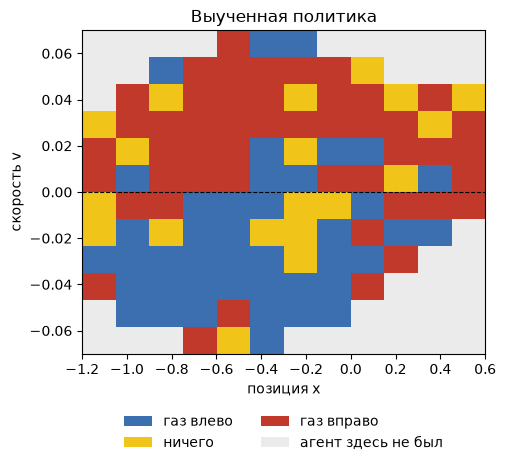

клеток, где элита ни разу не была: 35 из 144


In [32]:
# Как выглядит выученная политика.
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# В клетках, куда элита ни разу не попадала, политика осталась равномерной:
# argmax там ничего не значит и закрасил бы полкартинки ложным «газ влево». Прячем их.
grid = np.argmax(policy_mc.reshape(NBINS, NBINS, 3), axis=2).astype(float)
grid[visits.reshape(NBINS, NBINS) == 0] = np.nan

colors = ["#3b6fb0", "#f0c419", "#c0392b"]      # 0 = газ влево, 1 = ничего, 2 = газ вправо
cmap = ListedColormap(colors); cmap.set_bad("#ebebeb")

plt.figure(figsize=(5.2, 4.2))
plt.imshow(grid.T, origin="lower", cmap=cmap, vmin=-0.5, vmax=2.5,
           extent=[LOW[0], HIGH[0], LOW[1], HIGH[1]], aspect="auto")
plt.axhline(0, color="k", lw=0.8, ls="--")
plt.xlabel("позиция x"); plt.ylabel("скорость v")
plt.title("Выученная политика")
plt.legend(handles=[Patch(facecolor=c, label=l) for c, l in
                    zip(colors + ["#ebebeb"], ["газ влево", "ничего", "газ вправо", "агент здесь не был"])],
           loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
plt.show()
print(f"клеток, где элита ни разу не была: {int((visits == 0).sum())} из {NBINS * NBINS}")

In [33]:
# И как она едет.
rng = np.random.default_rng(0)
mc_render = gym.make("MountainCar-v0", render_mode="rgb_array", max_episode_steps=200)
obs, _ = mc_render.reset(seed=3)
frames, t = [], 0
while True:
    if t % 4 == 0:
        frames.append(mc_render.render())
    a = int(rng.choice(3, p=policy_mc[encode(obs)]))
    obs, r, terminated, truncated, _ = mc_render.step(a)
    t += 1
    if terminated or truncated:
        break
mc_render.close()
show_frames(frames, f"Политика, выученная CEM: {'доехал' if terminated else 'не доехал'} за {t} шагов")

Агент сам, без единой подсказки о физике, пришёл к правилу «газ в ту сторону, куда уже едешь», то есть переоткрыл эвристику из раздела 7, которую там придумал человек. Красная область (газ вправо) — положительные скорости, синяя (газ влево) — отрицательные. Серые клетки — сочетания позиции и скорости, в которых элита ни разу не оказывалась: там политика осталась равномерной. Это обычная картина для табличных методов: агент знает только то, что успел посетить.

### 12.9 Итог раздела

Что мы получили: рабочий алгоритм RL из трёх шагов — сыграть, отобрать лучшее, повторять то, что делали в лучшем. Никаких нейросетей, никакого знания среды, три функции по десять строк.

Где у него границы:

* нужны **дискретные** состояния и действия (или дискретизация, а она плохо масштабируется: сетка $12^2$ ещё ничего, $12^{17}$ для гуманоида уже невозможна);
* нужно **много эпизодов**: политика оценивается только целыми траекториями, информация об отдельных шагах не используется;
* плохо работает при **разрежённой награде** и в сильно **случайных** средах.

Куда двигаться дальше:

* **неделя 3** — продолжение линии раздела 11: ценности состояний и уравнение Беллмана, методы, которые извлекают информацию из **каждого шага**, а не из целого эпизода, и потому куда экономнее по данным;
* **неделя 5** — та же схема CEM, но таблица заменяется нейросетью, а шаг 3 — градиентным спуском по кросс-энтропии: тот же алгоритм решает CartPole и LunarLander.

## 13. Карта курса и итоги

![course](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/course_map.png)

Первые четыре недели — **основы**: постановка задачи, построение сред, табличные value-based и policy-based методы. Дальше те же идеи переносим на нейросети (**deep RL**: DQN, policy gradient, actor-critic), потом продвинутые методы (PPO, TD3, model-based), и расширения: иерархический и многоагентный RL, трансформеры.

![taxonomy](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/rl_taxonomy.png)

Всё, что в этой таблице, мы **реализуем сами** с нуля: от Cross-Entropy до PPO и TD3. RL-алгоритмы печально известны тем, что «почти работающая» реализация не работает вовсе, и понять, где ошибка, можно только зная каждую строчку.

## Итоги лекции

1. **RL — отдельный вид машинного обучения, и у него свой круг задач.** Нет правильных ответов, награда отложена, данные порождает сам агент, нужно исследовать. Ни одной из этих черт нет в supervised и unsupervised learning, зато они есть везде: от нард и го до дата-центров, дронов и языковых моделей.
2. **Словарь RL — это код, а не определения.** Состояние, действие, награда, эпизод, политика-таблица, return, MDP — всё это мы увидели на одном озере в нескольких строках Gymnasium. Ценность состояния — «средний return отсюда» — читается прямо с тепловой карты.
3. **Первый алгоритм: измерить и улучшить.** Политику измеряют, играя ей много раз (Монте-Карло); улучшают, повторяя действия из лучших эпизодов (Cross-Entropy). Три функции по десять строк решают озеро и учат машинку раскачиваться — а также объясняют, почему без случайности в политике и без запаса эпизодов ничего не работает.

Словарь, который нужно унести с собой: **агент, среда, состояние, действие, награда, политика, эпизод, терминальное состояние, return и дисконтирование, марковское свойство, MDP, исследование и использование, оценка политики методом Монте-Карло, ценность состояния, метод Cross-Entropy**.

## Литература

* R. Sutton, A. Barto. *Reinforcement Learning: An Introduction*, 2nd ed. — [бесплатный PDF](http://incompleteideas.net/book/the-book-2nd.html). Глава 1 — сегодняшняя лекция, главы 3–4 понадобятся на неделе 3.
* D. Silver. [UCL Course on RL](https://www.davidsilver.uk/teaching/), лекция 1: введение (лекция 2 про MDP — к неделе 3).
* А. Плаксин. [Курс imm-rl-lab](https://github.com/imm-rl-lab/reinforcement_learning_course), лекция 1: введение и метод Cross-Entropy.
* [OpenAI Spinning Up](https://spinningup.openai.com/) — короткое введение + чистые реализации.
* [Gymnasium](https://gymnasium.farama.org/) — документация по средам и интерфейсу.

## На семинаре и дома

* **Семинар** (`../seminar/seminar.ipynb`) идёт по лекции: интерфейс Gymnasium на Frozen Lake, политика-таблица руками, оценка политики и ценность клеток по Монте-Карло, метод Cross-Entropy по шагам с проверками, эксперименты со сглаживанием и скользким льдом.
* **ДЗ** (`../homework/homework.ipynb`): Cross-Entropy на Frozen Lake 8×8, оценка политики и ценность состояний, теория (return, марковская цепь, MDP на бумаге); бонусы — многорукие бандиты и DL-разминка.
* **Если вы не работали с нейросетями** — дорожка к неделе 5, по одному пункту в неделю:
  1. `../seminar/dl_basics.ipynb` — нейросети с нуля: модель с параметрами, функция потерь, градиентный спуск, первая сеть на PyTorch, классификация с кросс-энтропией (той самой, что в разделе 12.6);
  2. `../seminar/pytorch_intro.ipynb` — механика PyTorch, которая нужна именно в RL;
  3. упражнения из обоих ноутбуков — они же бонусная часть ДЗ 1;
  4. на неделе 5 нейросети появятся в лекции, и этого багажа хватит.